## **DATA UNDERSTANDING**

The Netflix dataset contains information about movies and TV shows available on Netflix. The dataset includes details such as title, content type, director, cast, country of origin, release year, rating, duration, and content categories. The data is used to analyze Netflix's content distribution and identify trends in its library.

# **Data Cleaning Process**

The Netflix dataset was cleaned using MySQL before being imported into Python for exploratory data analysis and visualization. Several data quality checks and transformations were performed to ensure the dataset was accurate, consistent, and suitable for analysis.

1. Missing Value Identification

The dataset was examined for missing or blank values across all columns. Missing values were found primarily in the Director, Cast, and Country columns.

2. Handling Missing Values

To maintain data completeness and avoid losing records, missing values in the Director, Cast, and Country columns were replaced with the value "Unknown". This ensured that all records remained available for analysis while clearly indicating unavailable information.

3. Duplicate Record Verification

A duplicate check was performed by comparing all columns in the dataset. No duplicate records were identified, indicating that each Netflix title was unique within the dataset.

4. Date Standardization

The Date Added column contained dates stored as text. These values were converted into a standardized date format (YYYY-MM-DD) using MySQL date conversion functions. The column data type was subsequently changed to the DATE format to support accurate date-based analysis.

5. Data Type Validation

Column data types were reviewed and adjusted where necessary to ensure consistency. Appropriate data types were assigned to text fields and date fields to improve data integrity and query performance.

6. Column Name Standardization

Column names were standardized to improve readability and maintain a consistent naming convention. For example:

show_id was renamed to ShowId
release_year was renamed to ReleaseYear
date_added was renamed to DateAdded
listed_in was renamed to ListedIn

This made the dataset easier to work with during analysis.

7. Data Validation

After cleaning, validation checks were performed to confirm that:

Missing values had been handled appropriately.
Column names were updated correctly.
Data types were consistent.
The dataset was ready for analysis and visualization.
Outcome

Following the cleaning process, the dataset was conducted for exploratory data analysis (EDA)

### **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) was conducted in MySQL to better understand the characteristics, distribution, and patterns within the Netflix dataset before creating visualizations.

**Statistical Analysis**

Descriptive statistics were calculated for the ReleaseYear variable, including:

Mean
Median
Minimum
Maximum
Standard Deviation

This provided insight into the distribution of content release years within the dataset.


**Duration Analysis**

Separate statistical analyses were performed for Movies and TV Shows.

For Movies, duration was analyzed in minutes.

For TV Shows, duration was analyzed based on the number of seasons.

Measures including mean, median, minimum, maximum, and standard deviation were calculated to understand typical content lengths.

**Content Distribution Analysis**

Several exploratory analyses were conducted to understand Netflix's content library, including:

Distribution of Movies and TV Shows
Number of titles added per year
Top content-producing countries
Most common audience ratings
Most common genres and categories

These analyses helped identify trends and patterns that were later explored through visualizations.

### **Visualization**

Following the completion of data cleaning in MySQL, the dataset was exported as a CSV file. The cleaned dataset was subsequently imported into Jupyter Notebook using Python, where final validation checks were conducted to verify the absence of duplicate records and missing values. After confirming the integrity of the dataset, visualizations were developed to examine content distribution, temporal trends, ratings, countries of production, and genre patterns. These visualizations formed the basis for the insights presented in this analysis.

## IMPORT LIBRARY #

In [9]:
## Importing Python Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATASET ##

In [10]:
df = pd.read_csv('/content/netflix_titles_cleaned.csv')
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

   date_added  release_year rating   duration  \
0  2021-09-25          2020  PG-13     90 min   
1  2021-09-24          2021  TV-MA  2 Seasons   
2  2021-09-24          2021  TV-MA   1 Season   
3  2

In [11]:
df.shape #### amountof rows and column in a file after cleaning

(8803, 12)

In [12]:
##data types and non empty cells count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8803 entries, 0 to 8802
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8803 non-null   object
 1   type          8803 non-null   object
 2   title         8803 non-null   object
 3   director      8803 non-null   object
 4   cast          8803 non-null   object
 5   country       8803 non-null   object
 6   date_added    8803 non-null   object
 7   release_year  8803 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8803 non-null   object
 10  listed_in     8803 non-null   object
 11  description   8803 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.4+ KB


In [13]:
##define column names
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
###finding the exact number of rows with missing values, per column
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [15]:
##checking for duplicates
checking_duplicates = df.duplicated() #Returns True or False
sum_of_duplicates = checking_duplicates.sum() #Returns total number of duplicates found in dataset

print("The total sum of duplicates is:", sum_of_duplicates)
print(checking_duplicates)

The total sum of duplicates is: 0
0       False
1       False
2       False
3       False
4       False
        ...  
8798    False
8799    False
8800    False
8801    False
8802    False
Length: 8803, dtype: bool


In [16]:
###summary statistics
df.describe () ### KPIS

,release_year
count,8803.000000
mean,2014.178803
std,8.820978
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [20]:
# Numerical Features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features:", numerical_features)

# Categorical Features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:", categorical_features)

# Possible Primary Key
print("Unique Show IDs:", df['show_id'].nunique())

Numerical Features: ['release_year']
Categorical Features: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'rating', 'duration', 'listed_in', 'description']
Unique Show IDs: 8803


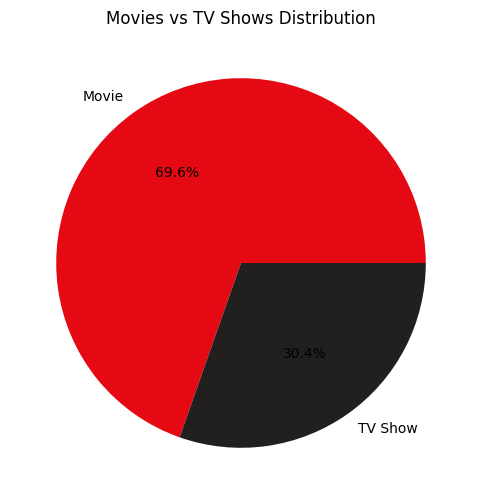

In [17]:
## Tv show vs Movie Distrubution
content_counts = df['type'].value_counts()


plt.figure(figsize=(6, 6))
plt.pie(content_counts.values,
        labels=content_counts.index,
        autopct='%1.1f%%',
        colors=['#E50914', '#221F1F'])
plt.title('Movies vs TV Shows Distribution')
plt.show()

The pie chart shows that movies make up 69.6% of the content available on the platform, while TV shows account for 30.4%. This indicates that movies are significantly more common than TV shows in the dataset, suggesting that the platform places a stronger emphasis on film content. The substantial difference in proportions highlights a greater focus on providing movie titles, with movies representing more than two-thirds of the platform's content library.

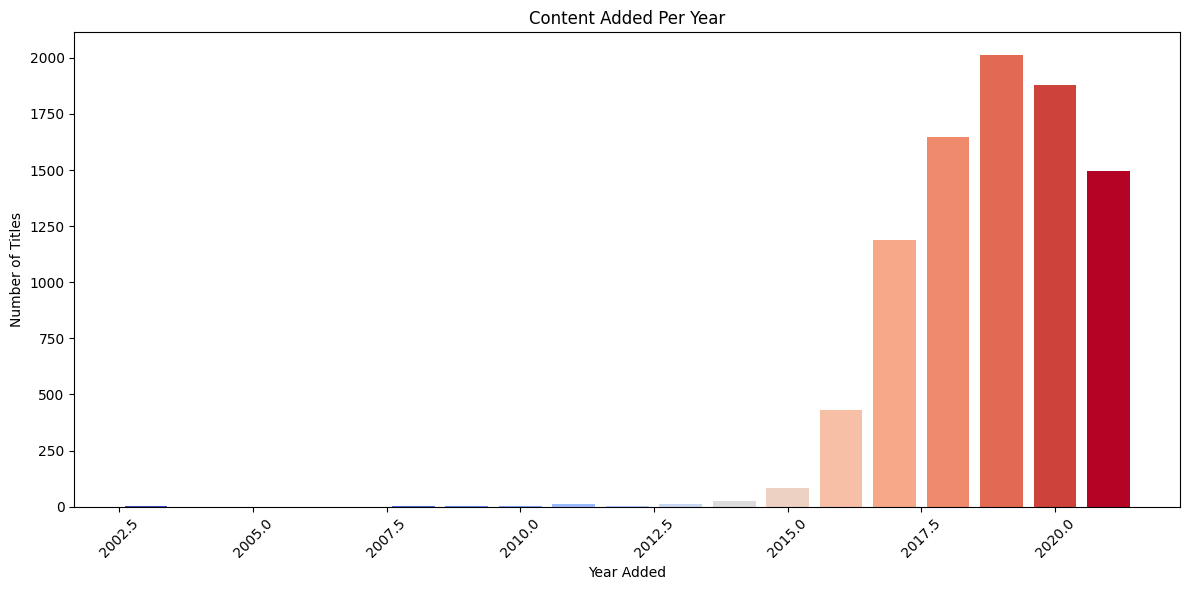

In [18]:
# Convert 'date_added' to datetime objects, coercing errors to NaT
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract the year from 'date_added' and drop rows with NaT in 'date_added'
df['year_added'] = df['date_added'].dt.year

# Count content per year added, dropping NaNs that resulted from unparseable dates
content_added_per_year = df['year_added'].dropna().astype(int).value_counts().sort_index()

# Get coolwarm colors
colors = plt.cm.coolwarm(np.linspace(0, 1, len(content_added_per_year)))

# Plot
plt.figure(figsize=(12, 6))
plt.bar(content_added_per_year.index, content_added_per_year.values, color=colors)
plt.title('Content Added Per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart illustrates the number of titles added to the platform each year. From 2008 to 2015, relatively few titles were added annually, indicating slow growth in the platform's content library during its early years. However, there was a sharp increase from 2016 onwards, with the number of additions rising significantly each year. The platform reached its peak in 2019, when just over 2,000 titles were added. Although the number of additions declined slightly in 2020 and 2021, it remained substantially higher than in previous years. Overall, the chart suggests that the platform experienced rapid expansion in its content library between 2016 and 2019, followed by a slight slowdown while maintaining a high volume of new content.

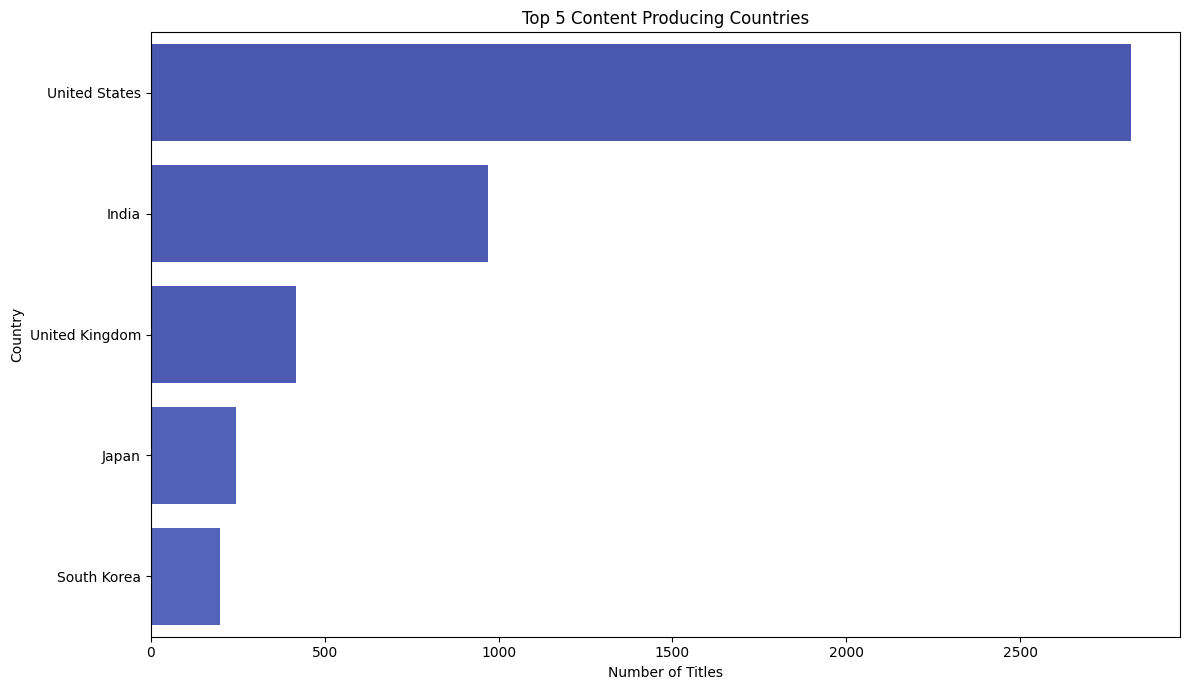

In [19]:
# Top Content Producing Countries
plt.figure(figsize=(12, 7))
sns.countplot(y='country', data=df[df['country'] != 'Unknown'],
  order=df[df['country'] != 'Unknown']['country'].value_counts().index[:5],
  palette='coolwarm', hue='country', legend=False)
plt.title('Top 5 Content Producing Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

The bar chart highlights the top five content-producing countries after removing records with unknown country information. Initially, "Unknown" had the highest number of titles in the dataset, but it was excluded from the analysis using the filter df[df['Country'] != 'Unknown'] to ensure that only identified countries were compared. Following this filtering, the United States emerged as the leading content producer with approximately 2,800 titles, significantly outperforming all other countries. India ranked second with around 1,000 titles, while the United Kingdom, Japan, and South Korea contributed approximately 420, 240, and 190 titles respectively. The results indicate that content production is heavily concentrated in a few countries, particularly the United States, which dominates the dataset by a substantial margin. This suggests that the platform's content library relies heavily on productions from the United States, with India also making a significant contribution compared to other countries.

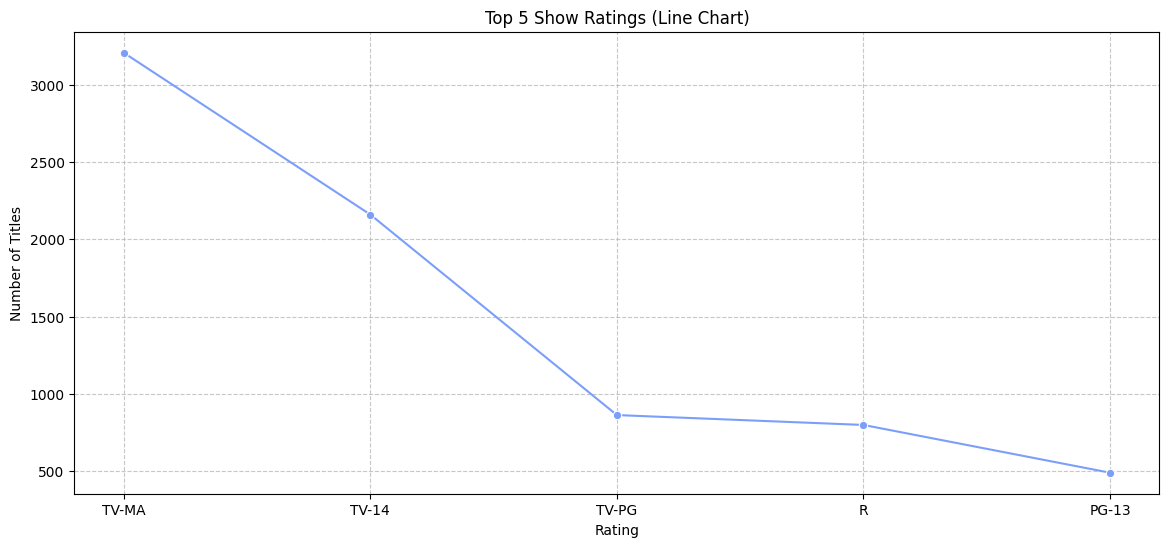

In [ ]:
# Most Common Ratings
top_5_ratings = df['rating'].value_counts().nlargest(5).reset_index()
top_5_ratings.columns = ['Rating', 'Count']

plt.figure(figsize=(14, 6))
sns.lineplot(x='Rating', y='Count', data=top_5_ratings, marker='o', color=plt.cm.coolwarm(0.2))
plt.title('Top 5 Show Ratings (Line Chart)')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The line chart shows that TV-MA is by far the most common content rating on the platform, with over 3,200 titles. This suggests that a significant portion of the content is aimed at mature audiences. TV-14 comes next with around 2,150 titles, showing that content for teenagers and older viewers also makes up a large share of the library. There is then a noticeable drop in the number of titles rated TV-PG, R, and PG-13, which have approximately 860, 800, and 490 titles respectively. Overall, the results indicate that the platform mainly focuses on content for mature and teenage audiences, while offering comparatively fewer titles designed for younger viewers and families.

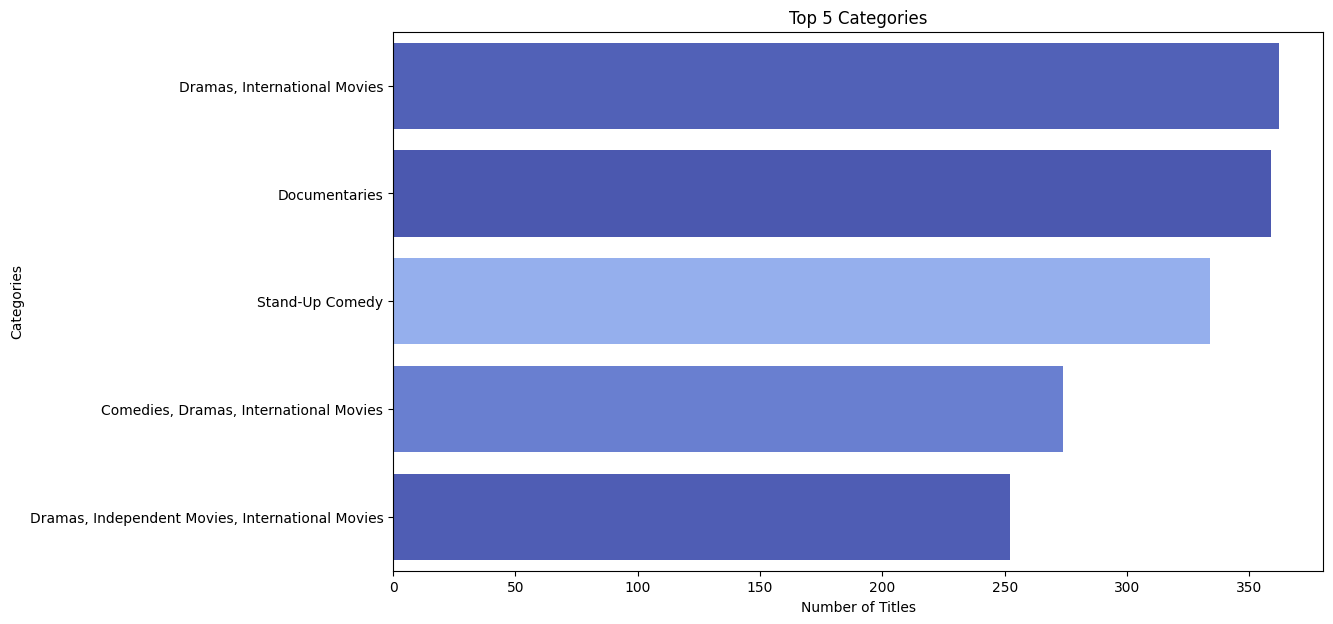

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(y='listed_in', data=df, order=df['listed_in'].value_counts().index[:5], palette='coolwarm', hue='listed_in', legend=False)
plt.title('Top 5 Categories')
plt.xlabel('Number of Titles')
plt.ylabel('Categories')
plt.show()

/tmp/ipykernel_8609/4147050788.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='release_year', y='listed_in', data=df_filtered, order=top_5_categories, palette='viridis')


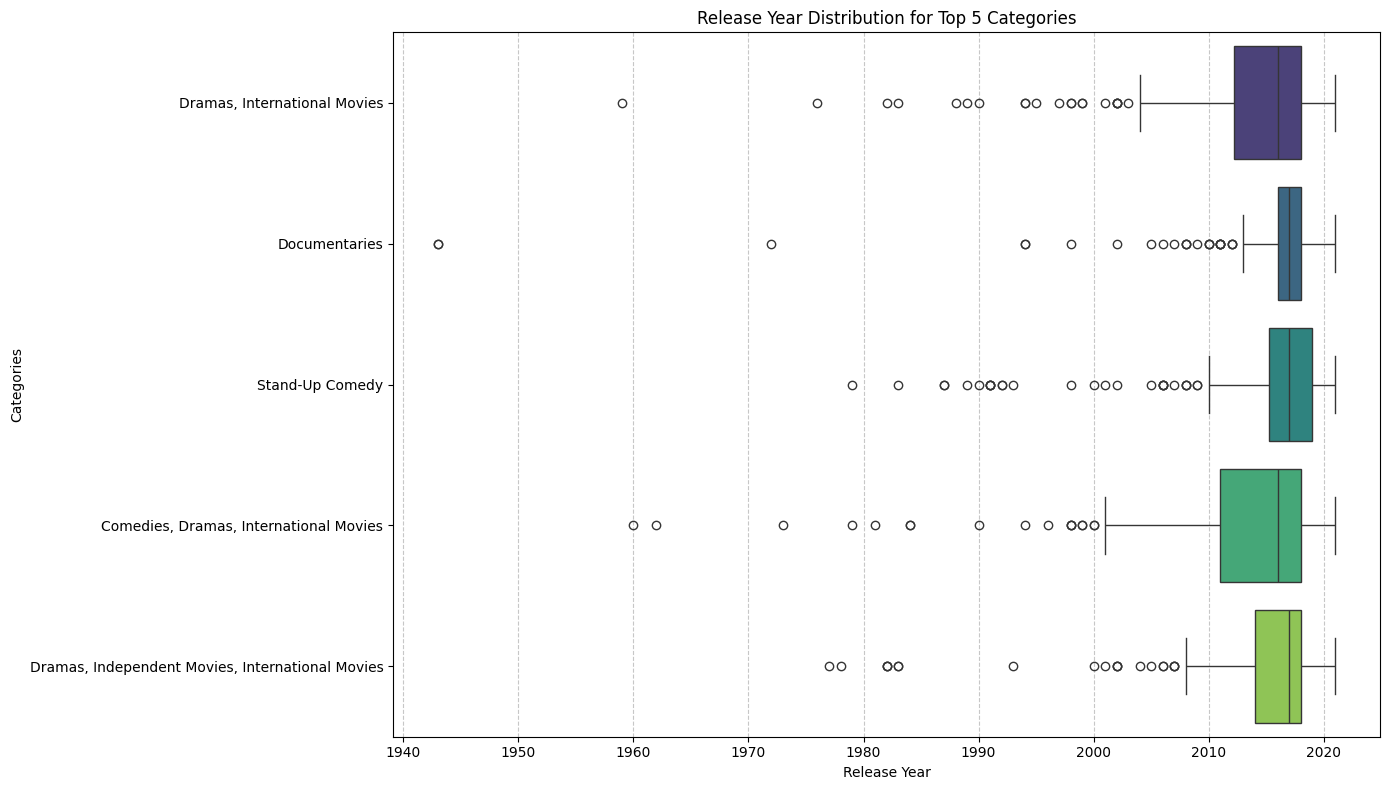

In [ ]:
top_5_categories = df['listed_in'].value_counts().index[:5]
df_filtered = df[df['listed_in'].isin(top_5_categories)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='release_year', y='listed_in', data=df_filtered, order=top_5_categories, palette='viridis')
plt.title('Release Year Distribution for Top 5 Categories')
plt.xlabel('Release Year')
plt.ylabel('Categories')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Two visualisations were used to explore the most common content categories in the dataset. The first graph, a bar chart, shows the top five categories based on the number of titles. Dramas, International Movies was the most common category with around 360 titles, closely followed by Documentaries. Stand-Up Comedy, Comedies, Dramas, International Movies, and Dramas, Independent Movies, International Movies also appeared frequently. This suggests that drama and international content are particularly popular on the platform, while documentaries and comedy-related content also make up a significant share of the library.

The second graph, a box plot, looks at how the release years are distributed within these categories. Most of the titles were released between 2010 and 2020, showing that the platform's most popular categories are largely made up of relatively recent content. However, there are also several older titles, with some dating back as far as the 1940s and 1950s. This is especially noticeable in categories such as Dramas, International Movies and Documentaries, which contain a wider range of release years than the other categories.

Looking at both graphs together provides a clearer picture of the platform's content. The bar chart highlights which categories appear most often, while the box plot shows how old or recent the content in those categories tends to be. Overall, the results suggest that the platform has a strong focus on drama, international movies, documentaries, and comedy content, with most titles being released in the last decade while still maintaining a selection of older titles.

### **KEY INSIGHTS**

## Key Insights

1. Movies dominate Netflix's content library, accounting for approximately 70% of all available titles. This suggests that Netflix places a stronger emphasis on film content than television series, likely to appeal to a broad global audience with diverse viewing preferences.

2. Content additions increased significantly between 2016 and 2019, reaching their highest level in 2019. This period reflects Netflix's rapid expansion strategy, during which the platform invested heavily in growing its content catalogue to attract and retain subscribers worldwide.

3. The United States is the largest content producing country in the dataset, contributing substantially more titles than any other nation. This highlights the continued influence of the US entertainment industry on Netflix's catalogue, while also demonstrating the platform's reliance on American produced content.

4. TV-MA is the most common content rating on Netflix, indicating that a large proportion of the platform's library is targeted towards mature audiences. This suggests that Netflix prioritises content designed for adults and older viewers over content aimed primarily at children and families.

5. Drama and International Movies are the most common content categories, demonstrating Netflix's strong focus on globally accessible storytelling. The prominence of international content also reflects the platform's efforts to serve audiences across different countries, cultures, and languages.
